# Retieving data from WEkEO

In [1]:
import earthkit.data as ekd

The :ref:`wekeo <data-sources-wekeo>` and :ref:`wekeocds <data-sources-wekeocds>` sources provide access to `WEkEO <https://www.wekeo.eu/>`_.

#### Using the WEkEO grammar

This example demonstrates how to access data from the WEkEO catalogue.

To retrieve data using the WEkEO grammar (see the `hda <https://hda.readthedocs.io/>`_ documentation), use the :ref:`wekeo <data-sources-wekeo>` source.

The dataset used here is `Vegetation Phenology and Productivity, yearly, UTM projection <https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:EEA:DAT:CLMS_HRVPP_VPP>`_.

The example retrieves the Total Productivity variable, representing the integral of vegetation productivity accumulated over the growing season as the sum of daily values. The product is derived from Copernicus Sentinel-2 observations and distributed in GeoTIFF format using 1°×1° tiles at a spatial resolution of 10 × 10 m.

In [17]:
ds = ekd.from_source(
    "wekeo",
    "EO:EEA:DAT:CLMS_HRVPP_VPP",
    request={
        "dataset_id": "EO:EEA:DAT:CLMS_HRVPP_VPP",
        "productType": "TPROD",
        "productGroupId": "s1",
        "tileId": "32TQR",
        "resolution": "10",
        "startdate": "2023-01-01T00:00:00.000Z",
        "enddate": "2023-01-01T23:59:59.999Z",
        "bbox": [12.28091069558975, 45.40759897973081, 12.384715295944709, 45.45978517718846],
    },
)

In [15]:
ds[0].to_xarray()

<xarray.DataArray 'Total productivity (Large integral) 2023-season1' (y: 10980,
                                                                      x: 10980)> Size: 482MB
[120560400 values with dtype=float32]
Coordinates:
  * y            (y) float64 88kB 5.1e+06 5.1e+06 5.1e+06 ... 4.99e+06 4.99e+06
  * x            (x) float64 88kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.098e+05
    spatial_ref  int64 8B 0
Attributes:
    PhysRange:  0 to 1095
    long_name:  Total productivity (Large integral) 2023-season1
    units:      -

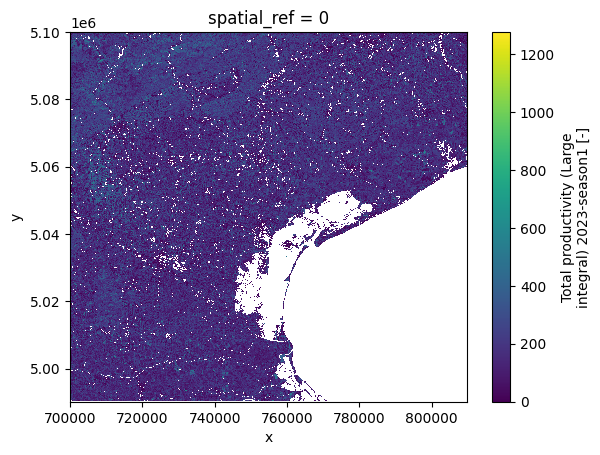

In [16]:
ds[0].to_xarray().plot()

####  Using the CDSAPI grammar

The following example retrieves ERA5 surface data in GRIB format:

In [5]:
import earthkit.data as ekd

ds = ekd.from_source(
    "wekeocds",
    "EO:ECMWF:DAT:REANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS",
    request=dict(
        variable=["2m_temperature", "mean_sea_level_pressure"],
        product_type=["monthly_averaged_reanalysis_by_hour_of_day"],
        year="2012",
        month="12",
        time="12:00",
        data_format="grib",
        download_format="zip",
    ),
)

ds.to_fieldlist().ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,2t,surface,0,20121201,1200,0,an,0,regular_ll
1,ecmf,msl,surface,0,20121201,1200,0,an,0,regular_ll
